## 1. Imports e carregamento

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# 1. Carregar o CSV de resultados
df = pd.read_csv("./data/dados__resultados_teste_classificacao.csv", sep=",", encoding="utf-8")

# Remover linhas de metadados (a segunda linha do CSV tem tipos de colunas)
df = df[pd.to_numeric(df["Gradient Boosting (II)"], errors="coerce").notna()].copy()

print(f"Shape: {df.shape}")
df.head()

Shape: (5274, 232)


C:\Users\clara\AppData\Local\Temp\ipykernel_15540\3397745507.py:18: DtypeWarning: Columns (0: Gradient Boosting (II), 1: Gradient Boosting (MI), 2: Gradient Boosting (MM), 3: Gradient Boosting (MS), 4: Gradient Boosting (error), 5: TP_DEPENDENCIA, 6: TP_LOCALIZACAO, 7: CO_ENTIDADE, 8: IN_LOCAL_FUNC_PREDIO_ESCOLAR, 9: TP_OCUPACAO_PREDIO_ESCOLAR, 10: CO_UF, 11: IN_LOCAL_FUNC_UNID_PRISIONAL, 12: IN_LOCAL_FUNC_PRISIONAL_SOCIO, 13: IN_LOCAL_FUNC_SALAS_OUTRA_ESC, 14: IN_LOCAL_FUNC_SOCIOEDUCATIVO, 15: IN_PREDIO_COMPARTILHADO, 16: IN_AGUA_POTAVEL, 17: IN_AGUA_REDE_PUBLICA, 18: IN_LOCAL_FUNC_GALPAO, 19: IN_AGUA_POCO_ARTESIANO, 20: TP_OCUPACAO_GALPAO, 21: IN_AGUA_CACIMBA, 22: IN_AGUA_FONTE_RIO, 23: IN_AGUA_CARRO_PIPA, 24: IN_ENERGIA_RENOVAVEL, 25: IN_ESGOTO_REDE_PUBLICA, 26: IN_ESGOTO_FOSSA_SEPTICA, 27: IN_ESGOTO_FOSSA_COMUM, 28: IN_AGUA_INEXISTENTE, 29: IN_ESGOTO_FOSSA, 30: IN_ESGOTO_INEXISTENTE, 31: IN_ENERGIA_REDE_PUBLICA, 32: IN_LIXO_SERVICO_COLETA, 33: IN_ENERGIA_GERADOR_FOSSIL, 34: IN_LIXO

,ROTULO_IDEB,Gradient Boosting,Gradient Boosting (II),Gradient Boosting (MI),Gradient Boosting (MM),Gradient Boosting (MS),Gradient Boosting (error),SG_UF,TP_DEPENDENCIA,TP_LOCALIZACAO,...,IN_ESP_EXCLUSIVA_PRE,IN_ESP_EXCLUSIVA_FUND_AI,IN_ESP_EXCLUSIVA_FUND_AF,IN_ESP_EXCLUSIVA_MEDIO_MEDIO,IN_ESP_EXCLUSIVA_MEDIO_INTEGR,IN_COMUM_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_FUND,IN_ESP_EXCLUSIVA_EJA_MEDIO,IN_ESP_EXCLUSIVA_EJA_PROF,IN_ESP_EXCLUSIVA_PROF
2,MI,MI,0.00199506,0.716231,0.281704,6.99413e-05,0.283769,PB,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,MI,MI,0.00371213,0.831326,0.164904,5.86693e-05,0.168674,MG,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,MI,MI,0.0029355,0.645729,0.351284,5.16525e-05,0.354271,SP,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,MI,MI,0.00186919,0.840804,0.157218,0.000109382,0.159196,SC,2,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,MM,MM,0.00262944,0.491815,0.50546,9.57515e-05,0.49454,PR,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Definir colunas e preparar dados
## Rótulos IDEB 2025

| Sigla | Significado      | Faixa                  |
|-------|------------------|------------------------|
| SS    | Superior         | 9,0 a 10               |
| MS    | Médio Superior   | 7,0 a 8,9              |
| MM    | Médio            | 5,0 a 6,9              |
| MI    | Médio Inferior   | 3,0 a 4,9              |
| II    | Inferior         | 0,0 a 2,9              |
| SR    | Sem Rendimento   | Zero (ou ausente/nulo) |

In [7]:
# Colunas de probabilidade do modelo
PROB_COLS = [
    "Gradient Boosting (II)",
    "Gradient Boosting (MI)",
    "Gradient Boosting (MM)",
    "Gradient Boosting (MS)"
]
CLASSES = ["II", "MI", "MM", "MS"]

# Converter para numérico
for col in PROB_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Classe prevista = argmax das probabilidades
df["PREDITO"] = df[PROB_COLS].idxmax(axis=1).str.extract(r"\((\w+)\)")[0]

# Classe real
df["REAL"] = df["ROTULO_IDEB"].astype(str).str.strip()

# Confiança da previsão
df["CONFIANCA"] = df[PROB_COLS].max(axis=1)

# Remover classes não usadas no treino (SS e SR não aparecem nas probs)
df = df[df["REAL"].isin(CLASSES)].copy()

print(f"Registros válidos: {len(df)}")
print("\nDistribuição real:")
print(df["REAL"].value_counts().reindex(CLASSES))
print("\nDistribuição prevista:")
print(df["PREDITO"].value_counts().reindex(CLASSES))

Registros válidos: 5274

Distribuição real:
REAL
II      81
MI    4054
MM    1127
MS      12
Name: count, dtype: int64

Distribuição prevista:
PREDITO
II      33
MI    4633
MM     595
MS      13
Name: count, dtype: int64


## Métricas gerais

In [8]:
# Métricas globais
acc = accuracy_score(df["REAL"], df["PREDITO"])
f1_macro = f1_score(df["REAL"], df["PREDITO"], average="macro")
f1_weighted = f1_score(df["REAL"], df["PREDITO"], average="weighted")
prec = precision_score(df["REAL"], df["PREDITO"], average="macro", zero_division=0)
rec = recall_score(df["REAL"], df["PREDITO"], average="macro", zero_division=0)

print("=" * 50)
print("MÉTRICAS GERAIS")
print("=" * 50)
print(f"Acurácia........: {acc:.4f}")
print(f"F1 macro........: {f1_macro:.4f}")
print(f"F1 weighted.....: {f1_weighted:.4f}")
print(f"Precisão macro..: {prec:.4f}")
print(f"Recall macro....: {rec:.4f}")
print("=" * 50)

print("\nRelatório completo por classe:")
print(classification_report(df["REAL"], df["PREDITO"], labels=CLASSES, zero_division=0))

MÉTRICAS GERAIS
Acurácia........: 0.8106
F1 macro........: 0.4459
F1 weighted.....: 0.7870
Precisão macro..: 0.5313
Recall macro....: 0.4159

Relatório completo por classe:
              precision    recall  f1-score   support

          II       0.45      0.19      0.26        81
          MI       0.83      0.95      0.89      4054
          MM       0.69      0.36      0.47      1127
          MS       0.15      0.17      0.16        12

    accuracy                           0.81      5274
   macro avg       0.53      0.42      0.45      5274
weighted avg       0.79      0.81      0.79      5274



## Matriz de confusão

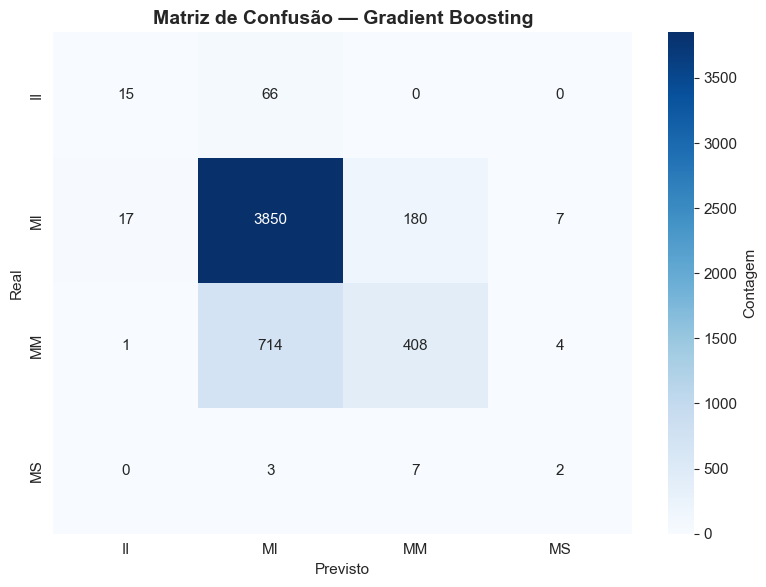

In [9]:
# Matriz de confusão
cm = confusion_matrix(df["REAL"], df["PREDITO"], labels=CLASSES)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
    cbar_kws={"label": "Contagem"}, ax=ax
)
ax.set_title("Matriz de Confusão — Gradient Boosting",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## Matriz de confusão normalizada (%)

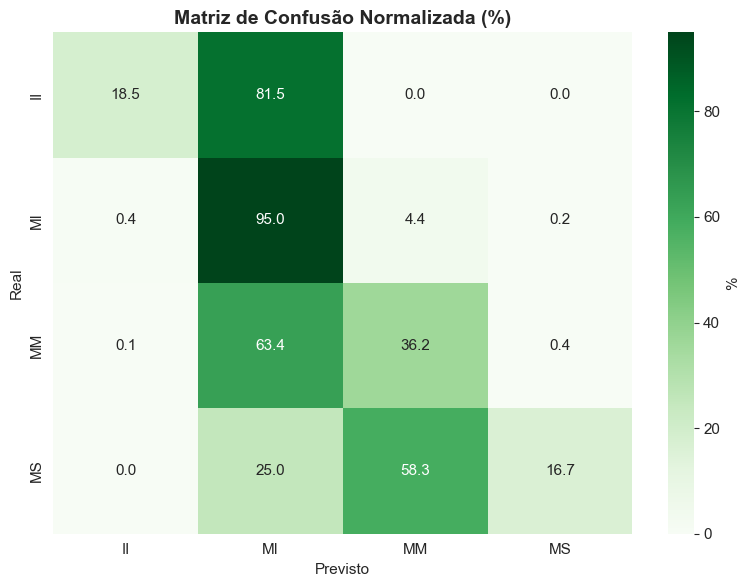

In [10]:
# Normalizada por linha (recall visual)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_norm, annot=True, fmt=".1f", cmap="Greens",
    xticklabels=CLASSES, yticklabels=CLASSES,
    cbar_kws={"label": "%"}, ax=ax
)
ax.set_title("Matriz de Confusão Normalizada (%)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

## Distribuição real vs prevista

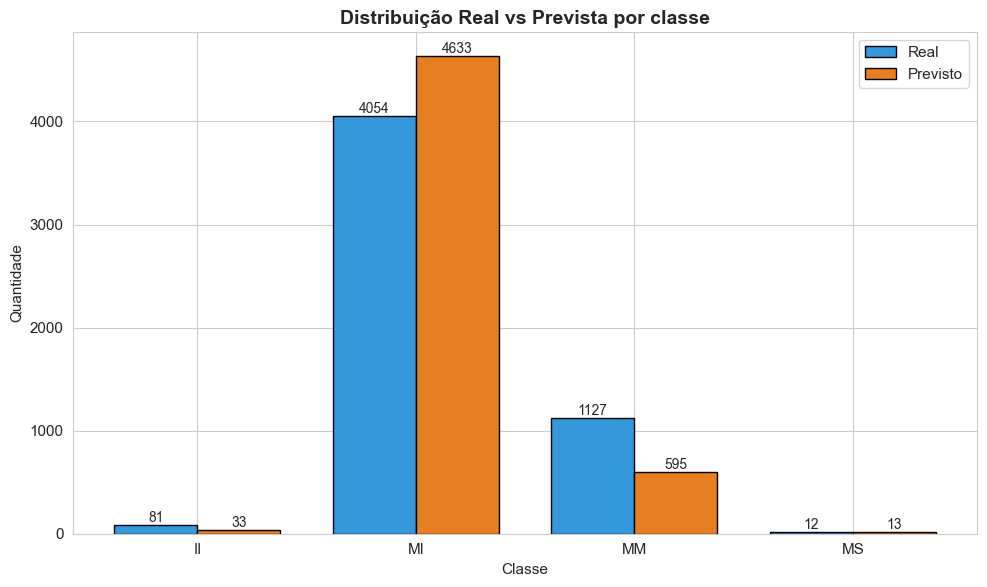

In [11]:
real_counts = df["REAL"].value_counts().reindex(CLASSES, fill_value=0)
pred_counts = df["PREDITO"].value_counts().reindex(CLASSES, fill_value=0)

x = np.arange(len(CLASSES))
width = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, real_counts.values, width, label="Real",
               color="#3498db", edgecolor="black")
bars2 = ax.bar(x + width/2, pred_counts.values, width, label="Previsto",
               color="#e67e22", edgecolor="black")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f"{int(h)}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_title("Distribuição Real vs Prevista por classe",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade")
ax.legend()
plt.tight_layout()
plt.show()

## Distribuição da confiança do modelo

C:\Users\clara\AppData\Local\Temp\ipykernel_15540\451922002.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


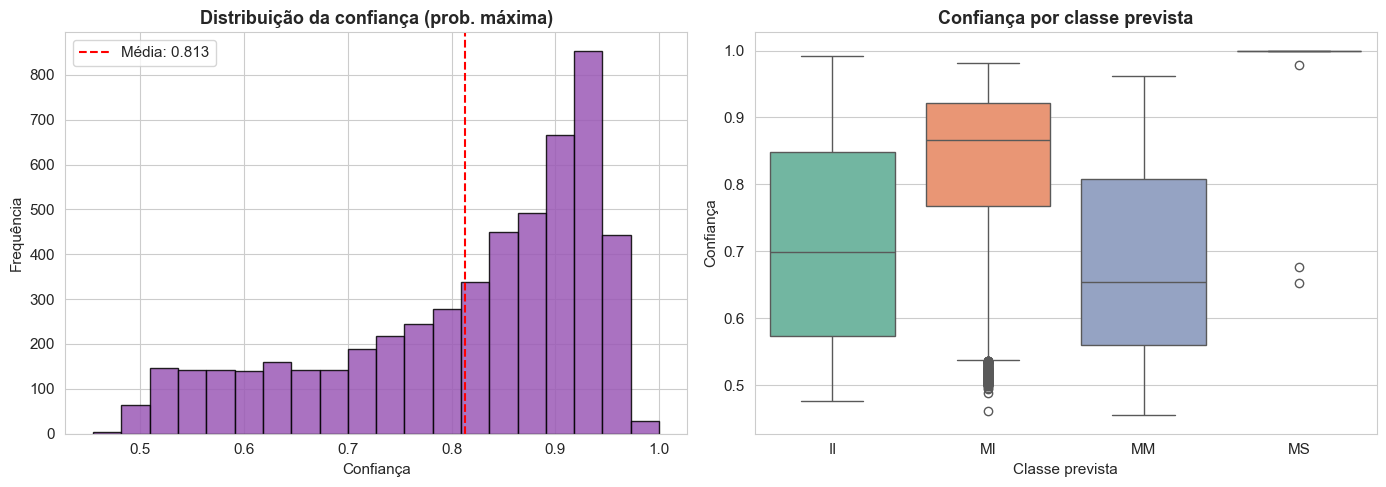

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma geral
axes[0].hist(df["CONFIANCA"], bins=20, color="#9b59b6",
             edgecolor="black", alpha=0.85)
axes[0].axvline(df["CONFIANCA"].mean(), color="red", linestyle="--",
                label=f"Média: {df['CONFIANCA'].mean():.3f}")
axes[0].set_title("Distribuição da confiança (prob. máxima)",
                  fontsize=13, fontweight="bold")
axes[0].set_xlabel("Confiança")
axes[0].set_ylabel("Frequência")
axes[0].legend()

# Boxplot por classe prevista
sns.boxplot(
    data=df, x="PREDITO", y="CONFIANCA",
    order=CLASSES, palette="Set2", ax=axes[1]
)
axes[1].set_title("Confiança por classe prevista",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Classe prevista")
axes[1].set_ylabel("Confiança")

plt.tight_layout()
plt.show()

## Erros do modelo (casos mal classificados)

In [13]:
erros = df[df["REAL"] != df["PREDITO"]].copy()

print(f"Total de erros: {len(erros)} de {len(df)} ({len(erros)/len(df)*100:.2f}%)")
print("\nPrincipais confusões (Real → Previsto):")
if len(erros) > 0:
    confusoes = erros.groupby(["REAL", "PREDITO"]).size().sort_values(ascending=False)
    print(confusoes)
else:
    print("Nenhum erro! Para o conjunto de teste, o modelo acertou todas as previsões.")

Total de erros: 999 de 5274 (18.94%)

Principais confusões (Real → Previsto):
REAL  PREDITO
MM    MI         714
MI    MM         180
II    MI          66
MI    II          17
      MS           7
MS    MM           7
MM    MS           4
MS    MI           3
MM    II           1
dtype: int64


## Top-N erros com maior confiança

In [14]:
if len(erros) > 0:
    top_erros = erros.sort_values("CONFIANCA", ascending=False).head(10)
    cols_show = ["CO_ENTIDADE", "SG_UF", "REAL", "PREDITO", "CONFIANCA"] + PROB_COLS
    cols_show = [c for c in cols_show if c in top_erros.columns]
    display(top_erros[cols_show])
else:
    print("Sem erros para exibir.")

,CO_ENTIDADE,SG_UF,REAL,PREDITO,CONFIANCA,Gradient Boosting (II),Gradient Boosting (MI),Gradient Boosting (MM),Gradient Boosting (MS)
2781,52000028,GO,MM,MS,1.000000,1.156130e-10,7.184290e-08,3.475800e-08,1.000000
4551,52099849,GO,MM,MS,1.000000,1.721280e-10,3.930210e-08,2.970810e-07,1.000000
678,42000017,SC,MI,MS,1.000000,6.993660e-10,3.586230e-08,1.160620e-07,1.000000
4296,43362214,RS,MI,MS,1.000000,8.204420e-20,1.021040e-17,5.936430e-18,1.000000
1160,41015525,PR,MM,MS,1.000000,2.790300e-14,2.522550e-12,1.649560e-11,1.000000
5252,31158879,MG,MI,MS,0.999999,4.673750e-09,8.993680e-07,3.927830e-08,0.999999
2579,23259507,CE,MI,MS,0.999988,4.713170e-08,9.043330e-06,2.507340e-06,0.999988
247,23252650,CE,MI,MS,0.999987,5.059460e-08,1.204440e-05,1.033630e-06,0.999987
1664,23246260,CE,MI,MS,0.999985,1.865650e-08,1.339780e-05,1.133730e-06,0.999985
1111,32007000,ES,MI,MS,0.999950,5.764380e-08,3.740540e-05,1.293370e-05,0.999950


## Resumo final (tabela)

In [15]:
resumo = pd.DataFrame({
    "Classe": CLASSES,
    "Suporte (real)": [int((df["REAL"] == c).sum()) for c in CLASSES],
    "Previstos": [int((df["PREDITO"] == c).sum()) for c in CLASSES],
    "Acertos": [int(((df["REAL"] == c) & (df["PREDITO"] == c)).sum()) for c in CLASSES],
})
resumo["Recall (%)"] = (resumo["Acertos"] / resumo["Suporte (real)"] * 100).round(2)
resumo["Confiança média"] = [
    round(df.loc[df["PREDITO"] == c, "CONFIANCA"].mean(), 4) if (df["PREDITO"] == c).any() else 0
    for c in CLASSES
]

print("=" * 70)
print("RESUMO POR CLASSE")
print("=" * 70)
print(resumo.to_string(index=False))
print("=" * 70)

RESUMO POR CLASSE
Classe  Suporte (real)  Previstos  Acertos  Recall (%)  Confiança média
    II              81         33       15       18.52           0.7175
    MI            4054       4633     3850       94.97           0.8298
    MM            1127        595      408       36.20           0.6878
    MS              12         13        2       16.67           0.9468
